Professor: Alexandre Neves Louzada / Aluno: Caio Silva Lopes
# Desemprego no Brasil (2015–2024): análise exploratória e visualização
**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python · **Avaliação G1**

## 1. Introdução ao problema
O desemprego varia entre regiões, estados e momentos econômicos. Este notebook investiga:
1. Quais regiões/UFs apresentam as maiores taxas de desemprego?
2. Como a taxa evoluiu entre 2015 e 2024, e qual foi o efeito da pandemia (2020–2021)?
3. Renda média, vagas formais e inflação ajudam a explicar o desemprego?

## 2. Explicação da base de dados
Arquivo `simulacao_desemprego_brasil.csv`: **800 linhas × 14 colunas**, uma por UF × trimestre (20 UFs, 40 trimestres, 2015-T1 a 2024-T4). Base **simulada** para fins didáticos.

| Coluna | Descrição |
|---|---|
| `ano`, `trimestre`, `data` | Período da observação |
| `regiao`, `uf` | Localização |
| `populacao_ativa`, `empregados`, `desempregados` | Contagens de pessoas |
| `taxa_desemprego` | % de desempregados na população ativa |
| `renda_media` | Renda média (R$) |
| `setor_predominante` | Setor econômico dominante |
| `vagas_formais` | Vagas com carteira no trimestre |
| `inflacao` | Inflação (%) |
| `nivel_risco` | Baixo (<7%), Médio (7–10%), Alto (10–14%), Crítico (>14%) |

## 3. Leitura dos dados

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from database.db import limpar, engenharia, taxa_ponderada, criar_banco, carregar_do_banco, ORDEM_RISCO

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
def salvar(nome): plt.tight_layout(); plt.savefig(f"../imagens/{nome}.png", bbox_inches="tight"); plt.show()

raw = pd.read_csv("../dados/simulacao_desemprego_brasil.csv")
print(raw.shape); raw.head()

(800, 14)


,ano,trimestre,data,regiao,uf,populacao_ativa,empregados,desempregados,taxa_desemprego,renda_media,setor_predominante,vagas_formais,inflacao,nivel_risco
0,2015,1,2015-03-01,Norte,AM,1428772,1293887,134885,9.44,2539.67,Construção,9513,7.09,Médio
1,2015,1,2015-03-01,Norte,PA,4912808,4231410,681398,13.87,2536.28,Construção,3104,6.84,Alto
2,2015,1,2015-03-01,Norte,RO,3654834,3217078,437756,11.98,3185.87,Construção,57505,5.48,Alto
3,2015,1,2015-03-01,Norte,TO,3481897,3010863,471034,13.53,1933.31,Comércio,61208,6.76,Alto
4,2015,1,2015-03-01,Nordeste,BA,509015,425557,83458,16.40,3792.59,Serviços,47983,5.51,Crítico


In [2]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 800 non-null    int64  
 1   trimestre           800 non-null    int64  
 2   data                800 non-null    str    
 3   regiao              800 non-null    str    
 4   uf                  800 non-null    str    
 5   populacao_ativa     800 non-null    int64  
 6   empregados          800 non-null    int64  
 7   desempregados       800 non-null    int64  
 8   taxa_desemprego     800 non-null    float64
 9   renda_media         800 non-null    float64
 10  setor_predominante  800 non-null    str    
 11  vagas_formais       800 non-null    int64  
 12  inflacao            800 non-null    float64
 13  nivel_risco         800 non-null    str    
dtypes: float64(3), int64(6), str(5)
memory usage: 115.2 KB


## 4. Limpeza e preparação

In [3]:
print("Nulos:", raw.isna().sum().sum(), "| Duplicatas (data+uf):", raw.duplicated(["data","uf"]).sum())
print("empregados + desempregados == populacao_ativa:", ((raw.empregados + raw.desempregados) == raw.populacao_ativa).all())
print("taxa confere com desempregados/ativa:", (abs(raw.desempregados/raw.populacao_ativa*100 - raw.taxa_desemprego) < .05).all())
print("Faixas por nivel_risco:"); print(raw.groupby("nivel_risco").taxa_desemprego.agg(["min","max"]).round(2))
df = limpar(raw)   # tipos, padronização de texto, duplicatas e valores inválidos
print("\nApós limpeza:", df.shape, "| datas:", df.data.dt.year.min(), "–", df.data.dt.year.max())

Nulos: 0 | Duplicatas (data+uf): 0
empregados + desempregados == populacao_ativa: True
taxa confere com desempregados/ativa: True
Faixas por nivel_risco:
               min    max
nivel_risco              
Alto         10.01  13.99
Baixo         3.00   7.00
Crítico      14.02  20.53
Médio         7.00   9.98

Após limpeza: (800, 14) | datas: 2015 – 2024


**Diagnóstico:** a base já vem íntegra — sem nulos ou duplicatas, e os totais e taxas são consistentes. A limpeza converte `data` para datetime, padroniza textos e valida faixas. Como cada linha tem população ativa diferente, **médias simples de taxas distorcem agregados**; usamos a **taxa ponderada** (Σ desempregados / Σ população ativa).

## 5. Engenharia de atributos

In [4]:
df = engenharia(df)
novos = ["periodo","fase","vagas_por_mil","renda_real_proxy","mm4_taxa","var_anual_pp"]
df[["uf","data"] + novos].head(6)

,uf,data,periodo,fase,vagas_por_mil,renda_real_proxy,mm4_taxa,var_anual_pp
0,DF,2015-03-01,2015-T1,Pré-pandemia (2015-19),11.442299,1508.010869,7.74,NaN
1,GO,2015-03-01,2015-T1,Pré-pandemia (2015-19),2.255681,3584.610156,7.68,NaN
2,MS,2015-03-01,2015-T1,Pré-pandemia (2015-19),4.580861,3072.602103,8.64,NaN
3,MT,2015-03-01,2015-T1,Pré-pandemia (2015-19),14.322234,2852.259780,10.53,NaN
4,BA,2015-03-01,2015-T1,Pré-pandemia (2015-19),94.266377,3594.531324,16.40,NaN
5,CE,2015-03-01,2015-T1,Pré-pandemia (2015-19),21.037163,3293.000850,14.89,NaN


Novos atributos: `periodo` (ex.: 2015-T1), `fase` (pré/pandemia/pós), `vagas_por_mil` (vagas por mil ativos, comparável entre UFs), `renda_real_proxy` (renda deflacionada pela inflação do trimestre), `mm4_taxa` (média móvel de 4 trimestres por UF) e `var_anual_pp` (variação em p.p. vs. mesmo trimestre do ano anterior).

## 6. Análise exploratória

In [5]:
df.select_dtypes('number').drop(columns=['lat','lon']).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ano,800.0,2019.50,2.87,2015.00,2017.00,2019.50,2022.00,2024.00
trimestre,800.0,2.50,1.12,1.00,1.75,2.50,3.25,4.00
populacao_ativa,800.0,3217270.64,1650285.63,318431.00,1756632.25,3332223.00,4644644.00,5999399.00
empregados,800.0,2899966.74,1492184.44,275629.00,1583077.50,2999189.00,4163297.25,5665164.00
desempregados,800.0,317303.90,198400.48,15257.00,153360.75,296823.00,451212.00,923101.00
taxa_desemprego,800.0,9.90,3.23,3.00,7.56,9.82,12.26,20.53
renda_media,800.0,2790.65,581.40,1002.32,2396.18,2815.16,3176.67,4691.42
vagas_formais,800.0,44820.77,25624.24,1063.00,22070.25,44946.50,66820.25,89691.00
inflacao,800.0,4.98,1.58,-1.06,3.92,4.96,6.04,9.90
vagas_por_mil,800.0,23.03,30.54,0.21,7.44,13.63,25.11,268.66


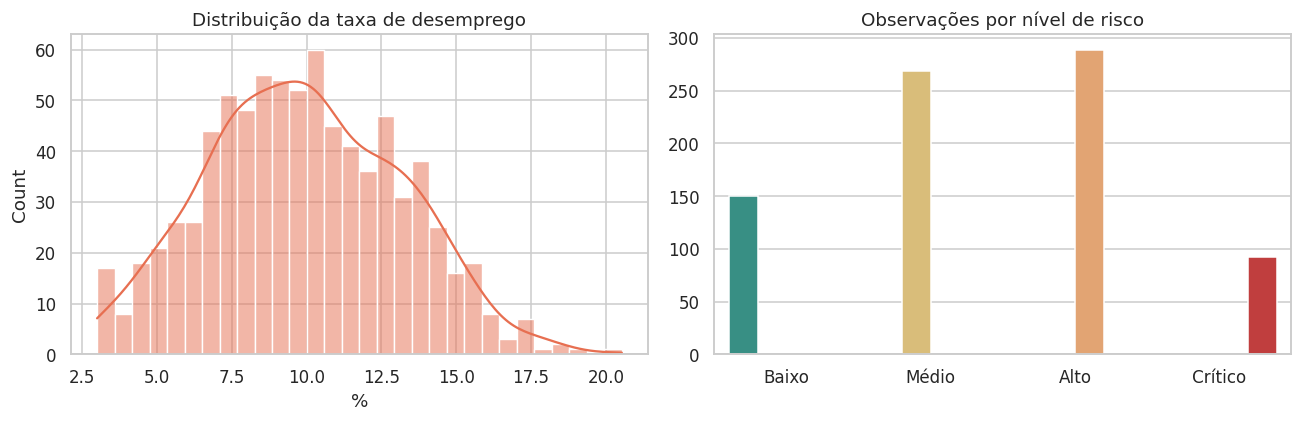

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.taxa_desemprego, bins=30, kde=True, color="#e76f51", ax=ax[0]); ax[0].set(title="Distribuição da taxa de desemprego", xlabel="%")
sns.countplot(data=df, x="nivel_risco", order=ORDEM_RISCO, hue="nivel_risco", palette=["#2a9d8f","#e9c46a","#f4a261","#d62828"], legend=False, ax=ax[1]); ax[1].set(title="Observações por nível de risco", xlabel="", ylabel="")
salvar("01_distribuicao")

## 7. Persistência em banco (SQLAlchemy + SQLite) e KPIs

In [7]:
criar_banco()                  # CSV limpo -> 3 tabelas relacionais (regioes, ufs, observacoes)
dfb = carregar_do_banco()      # JOIN entre as tabelas
print("Lido do banco:", dfb.shape)

kpis = {
 "Taxa de desemprego ponderada (%)": taxa_ponderada(dfb),
 "Taxa simples média (%)": dfb.taxa_desemprego.mean(),
 "Renda média (R$)": dfb.renda_media.mean(),
 "Vagas formais por mil ativos": dfb.vagas_por_mil.mean(),
 "Inflação média (%)": dfb.inflacao.mean(),
 "% observações em nível Crítico": (dfb.nivel_risco == "Crítico").mean()*100,
}
pd.Series(kpis).round(2).to_frame("valor")

Lido do banco: (800, 22)


,valor
Taxa de desemprego ponderada (%),9.86
Taxa simples média (%),9.90
Renda média (R$),2790.65
Vagas formais por mil ativos,23.03
Inflação média (%),4.98
% observações em nível Crítico,11.50


## 8. Gráficos

### 8.1 Evolução temporal por região (série com média móvel de 4 trimestres)

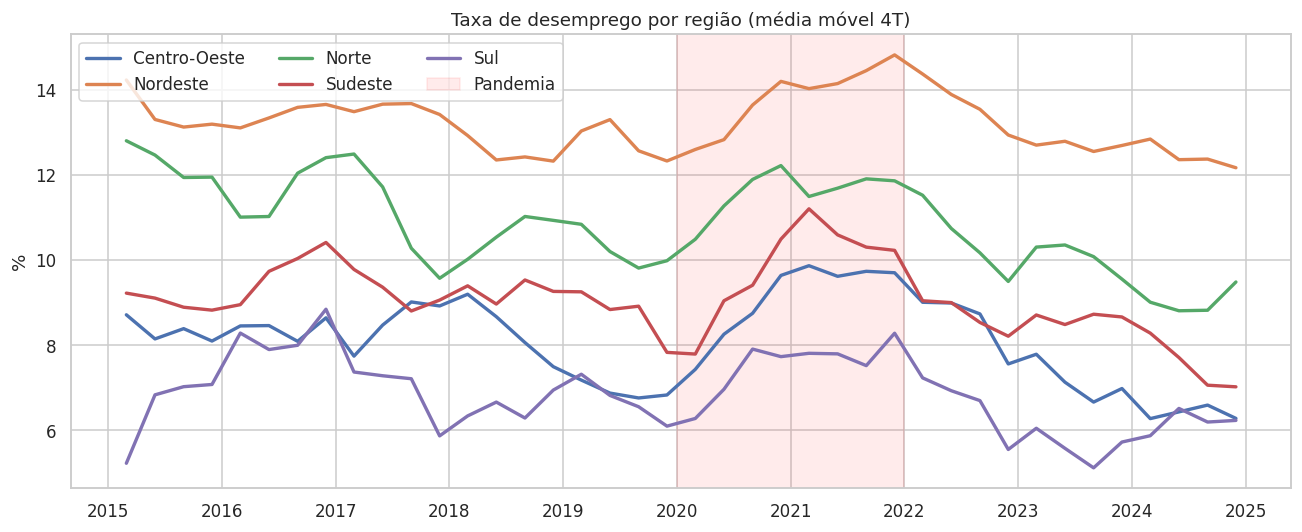

In [8]:
serie = dfb.groupby(["data","regiao"]).apply(taxa_ponderada).rename("taxa").reset_index()
serie["mm4"] = serie.groupby("regiao").taxa.transform(lambda s: s.rolling(4, min_periods=1).mean())
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=serie, x="data", y="mm4", hue="regiao", linewidth=2.2, ax=ax)
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=.08, label="Pandemia")
ax.set(title="Taxa de desemprego por região (média móvel 4T)", xlabel="", ylabel="%"); ax.legend(ncol=3)
salvar("02_serie_temporal")

### 8.2 Comparativo entre regiões

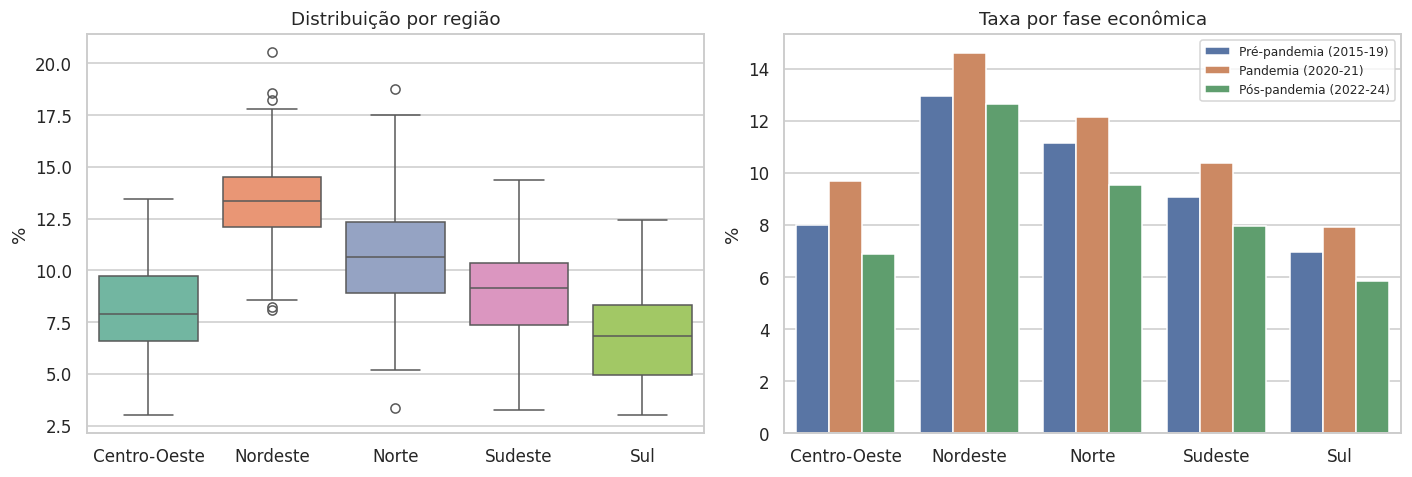

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=dfb, x="regiao", y="taxa_desemprego", hue="regiao", palette="Set2", legend=False, ax=ax[0]); ax[0].set(title="Distribuição por região", xlabel="", ylabel="%")
fase = dfb.groupby(["fase","regiao"]).apply(taxa_ponderada).rename("taxa").reset_index()
sns.barplot(data=fase, x="regiao", y="taxa", hue="fase", hue_order=["Pré-pandemia (2015-19)","Pandemia (2020-21)","Pós-pandemia (2022-24)"], ax=ax[1])
ax[1].set(title="Taxa por fase econômica", xlabel="", ylabel="%"); ax[1].legend(fontsize=8)
salvar("03_regioes")

### 8.3 Ranking de UFs e mapa de calor

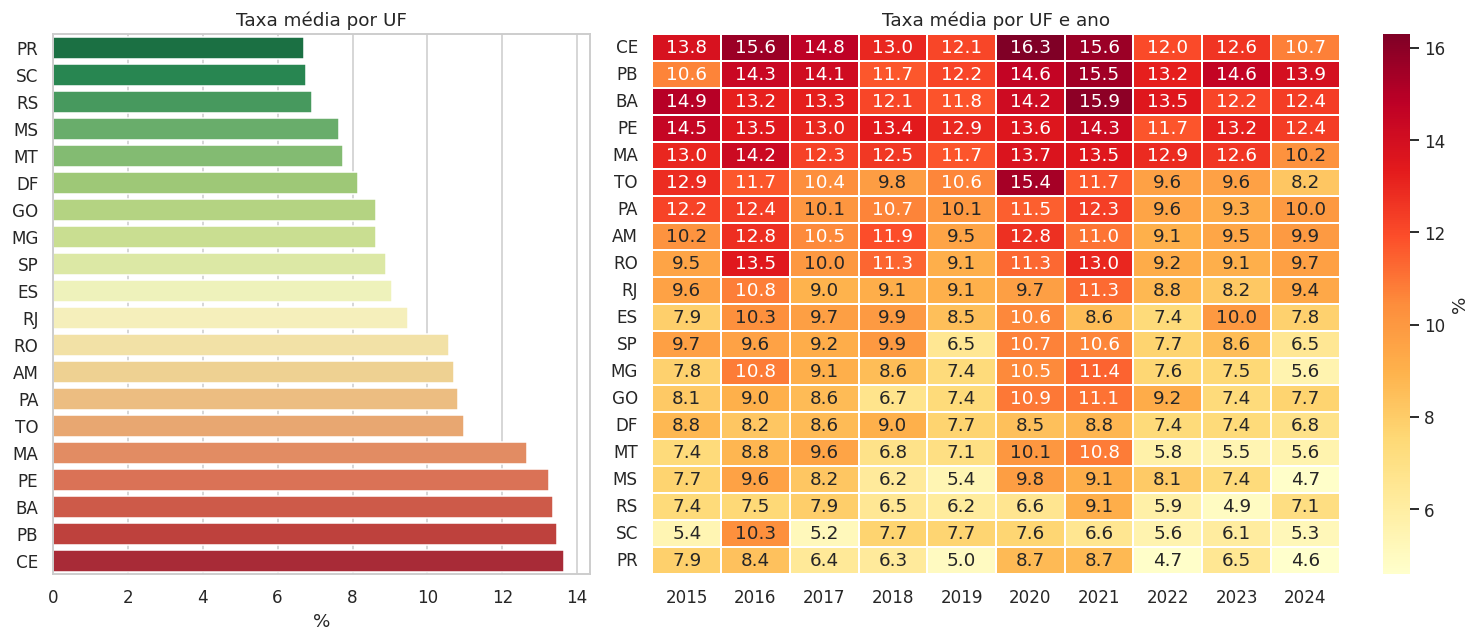

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[1,1.6]})
rk = dfb.groupby("uf").taxa_desemprego.mean().sort_values()
sns.barplot(x=rk.values, y=rk.index, hue=rk.index, palette="RdYlGn_r", legend=False, ax=ax[0]); ax[0].set(title="Taxa média por UF", xlabel="%", ylabel="")
piv = dfb.pivot_table(index="uf", columns="ano", values="taxa_desemprego")
sns.heatmap(piv.loc[rk.index[::-1]], annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.3, ax=ax[1], cbar_kws={"label":"%"}); ax[1].set(title="Taxa média por UF e ano", xlabel="", ylabel="")
salvar("04_ranking_heatmap")

### 8.4 Níveis de risco por ano e setor

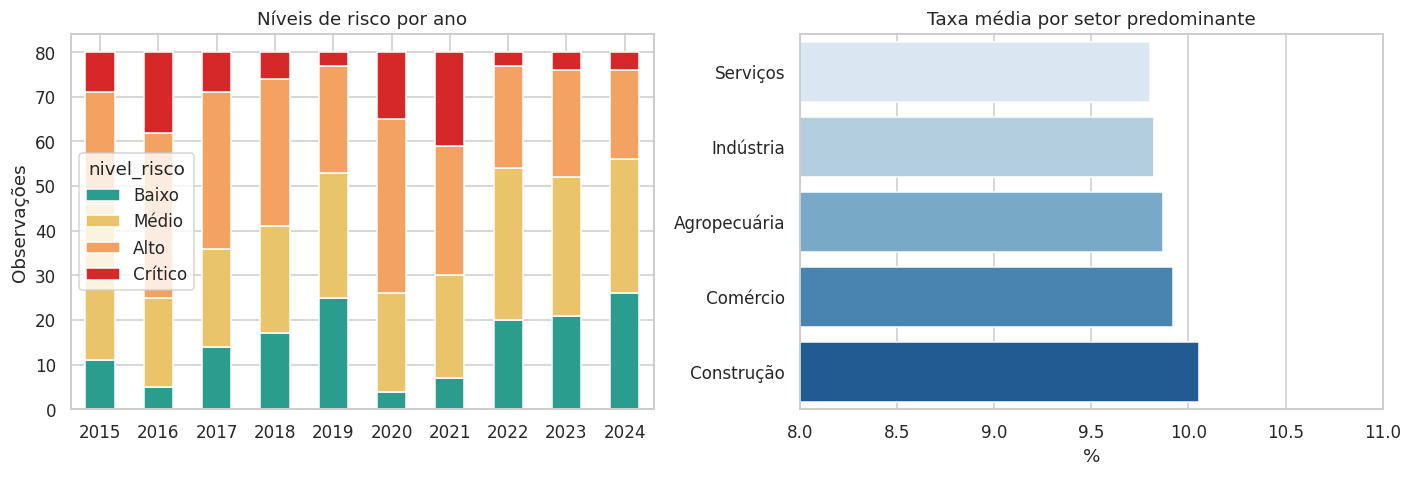

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
rr = pd.crosstab(dfb.ano, dfb.nivel_risco)[ORDEM_RISCO]
rr.plot(kind="bar", stacked=True, color=["#2a9d8f","#e9c46a","#f4a261","#d62828"], ax=ax[0]); ax[0].set(title="Níveis de risco por ano", xlabel="", ylabel="Observações"); ax[0].tick_params(axis="x", rotation=0)
st_ = dfb.groupby("setor_predominante").taxa_desemprego.mean().sort_values()
sns.barplot(x=st_.values, y=st_.index, hue=st_.index, palette="Blues", legend=False, ax=ax[1]); ax[1].set(title="Taxa média por setor predominante", xlabel="%", ylabel="")
ax[1].set_xlim(8, 11)
salvar("05_risco_setor")

### 8.5 Correlação estatística

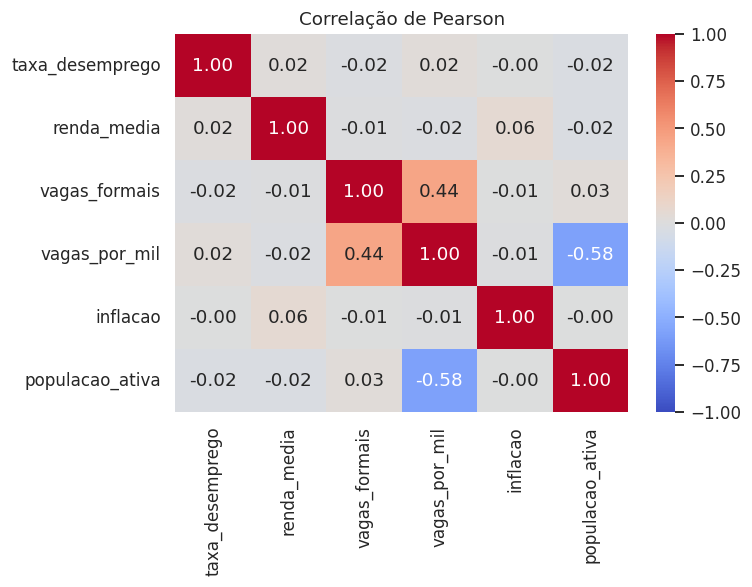

,variável,pearson_r,pearson_p,spearman_rho,spearman_p
0,renda_media,0.019,0.601,0.016,0.652
1,vagas_formais,-0.017,0.626,-0.014,0.683
2,vagas_por_mil,0.025,0.483,-0.007,0.836
3,inflacao,-0.004,0.918,0.004,0.899
4,populacao_ativa,-0.024,0.497,-0.012,0.738


In [12]:
cols = ["taxa_desemprego","renda_media","vagas_formais","vagas_por_mil","inflacao","populacao_ativa"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(dfb[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax); ax.set_title("Correlação de Pearson")
salvar("06_correlacao")
res = pd.DataFrame([(c, *stats.pearsonr(dfb[c], dfb.taxa_desemprego), *stats.spearmanr(dfb[c], dfb.taxa_desemprego)) for c in cols[1:]],
                   columns=["variável","pearson_r","pearson_p","spearman_rho","spearman_p"]).round(3)
res

## 9. Interpretação dos resultados

In [13]:
anual = dfb.groupby("ano").apply(taxa_ponderada).round(2)
reg = dfb.groupby("regiao").apply(taxa_ponderada).sort_values().round(2)
fases = dfb.groupby("fase").apply(taxa_ponderada).round(2)
print("Taxa anual:", anual.to_dict()); print("Por região:", reg.to_dict()); print("Por fase:", fases.to_dict())
print("Maior/menor UF:", rk.index[-1], round(rk.iloc[-1],2), "/", rk.index[0], round(rk.iloc[0],2))
print("% Crítico por fase:"); print((pd.crosstab(dfb.fase, dfb.nivel_risco, normalize="index")["Crítico"]*100).round(1))

Taxa anual: {2015: 9.75, 2016: 11.02, 2017: 10.1, 2018: 9.56, 2019: 8.79, 2020: 11.17, 2021: 11.37, 2022: 8.86, 2023: 9.21, 2024: 8.75}
Por região: {'Sul': 6.84, 'Centro-Oeste': 7.96, 'Sudeste': 9.01, 'Norte': 10.86, 'Nordeste': 13.18}
Por fase: {'Pandemia (2020-21)': 11.28, 'Pré-pandemia (2015-19)': 9.86, 'Pós-pandemia (2022-24)': 8.95}
Maior/menor UF: CE 13.65 / PR 6.71
% Crítico por fase:
fase
Pandemia (2020-21)        22.5
Pré-pandemia (2015-19)    11.2
Pós-pandemia (2022-24)     4.6
Name: Crítico, dtype: float64


- **Território:** o **Nordeste (13,2%)** e o **Norte (10,9%)** concentram as maiores taxas; o **Sul (6,8%)** tem a menor. CE, PB e BA lideram o ranking de UFs (≈13,4–13,7%) e PR, SC e RS fecham a lista (≈6,7–6,9%): gap de ~7 p.p. entre extremos.
- **Pandemia:** a taxa agregada passou de 9,9% (2015–19) para **11,3% (2020–21)** e recuou para **9,0% (2022–24)**. O pico foi 2021-T3 (≈11,8%). Observações em nível Crítico foram de ~11% para **22,5%** na pandemia e caíram para **4,6%** depois.
- **Setor:** diferenças mínimas (9,8% a 10,1%). Construção tem a taxa um pouco mais alta, mas a diferença não é discriminante.
- **Correlações:** renda, vagas formais, inflação e população ativa têm |r| < 0,03 com a taxa e p-valores > 0,49 — **sem relação estatística**. É esperado em dados simulados; em dados reais (PNAD) essas relações precisariam ser reavaliadas.

## 10. Conclusão
1. O desemprego é um fenômeno **territorial**: região e UF explicam bem mais que o setor predominante.
2. A **pandemia** elevou o desemprego em todas as regiões e dobrou a proporção de observações Críticas, com recuperação a partir de 2022.
3. Renda, vagas e inflação **não explicam** a taxa nesta base — alerta contra supor causalidade sem evidência.
4. **Recomendação:** focalizar políticas de emprego no Nordeste e Norte e manter mecanismos de resposta rápida a choques.
5. **Limitações:** base simulada, centroides de UF no mapa (sem polígonos) e apenas 20 das 27 UFs. Próximo passo: replicar com a PNAD Contínua (API SIDRA/IBGE).